In [1]:
import pandas as pd

df = pd.read_csv("C://Users/User/Downloads/train.csv")

# Convert date
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Remove missing
df.dropna(inplace=True)

ValueError: time data "15/04/2018" doesn't match format "%m/%d/%Y", at position 4. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [2]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

In [3]:
print(df['Order Date'].head())
print(df['Order Date'].dtype)

0   2017-11-08
1   2017-11-08
2   2017-06-12
3   2016-10-11
4   2016-10-11
Name: Order Date, dtype: datetime64[ns]
datetime64[ns]


In [4]:
df.dropna(inplace=True)

In [5]:
df['Month'] = df['Order Date'].dt.to_period('M')

In [6]:
df['Month']

0       2017-11
1       2017-11
2       2017-06
3       2016-10
4       2016-10
         ...   
9795    2017-05
9796    2016-01
9797    2016-01
9798    2016-01
9799    2016-01
Name: Month, Length: 9789, dtype: period[M]

In [8]:
df["Sales"]

0       261.9600
1       731.9400
2        14.6200
3       957.5775
4        22.3680
          ...   
9795      3.7980
9796     10.3680
9797    235.1880
9798     26.3760
9799     10.3840
Name: Sales, Length: 9789, dtype: float64

In [9]:
monthly_sales = df.groupby('Month')['Sales'].sum()
print(monthly_sales)

Month
2015-01     14205.7070
2015-02      4519.8920
2015-03     55205.7970
2015-04     27906.8550
2015-05     23644.3030
2015-06     34322.9356
2015-07     33781.5430
2015-08     27117.5365
2015-09     81623.5268
2015-10     31453.3930
2015-11     77907.6607
2015-12     68167.0585
2016-01     18066.9576
2016-02     11951.4110
2016-03     32339.3184
2016-04     34154.4685
2016-05     29959.5305
2016-06     23599.3740
2016-07     28608.2590
2016-08     36818.3422
2016-09     63133.6060
2016-10     31011.7375
2016-11     70129.2995
2016-12     74543.6012
2017-01     16870.1810
2017-02     22978.8150
2017-03     51165.0590
2017-04     37385.0170
2017-05     56656.9080
2017-06     39724.4860
2017-07     38320.7830
2017-08     30542.2003
2017-09     69193.3909
2017-10     59583.0330
2017-11     79066.4958
2017-12     95739.1210
2018-01     42839.2940
2018-02     19920.9974
2018-03     58863.4128
2018-04     35541.9101
2018-05     43825.9822
2018-06     48190.7277
2018-07     44825.1040
2018-

In [10]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False)
print(top_products.head(5))

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
Name: Sales, dtype: float64


In [11]:
region_sales = df.groupby('Region')['Sales'].sum()
print(region_sales)

Region
Central    492646.9132
East       660589.3560
South      389151.4590
West       710219.6845
Name: Sales, dtype: float64


In [12]:
import matplotlib.pyplot as plt

<Axes: xlabel='Month'>

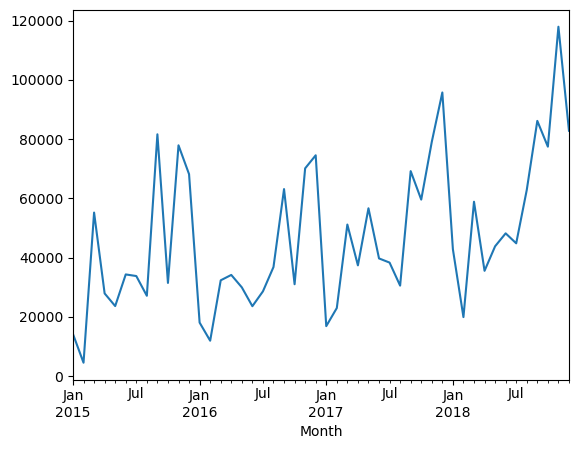

In [13]:
monthly_sales.plot()

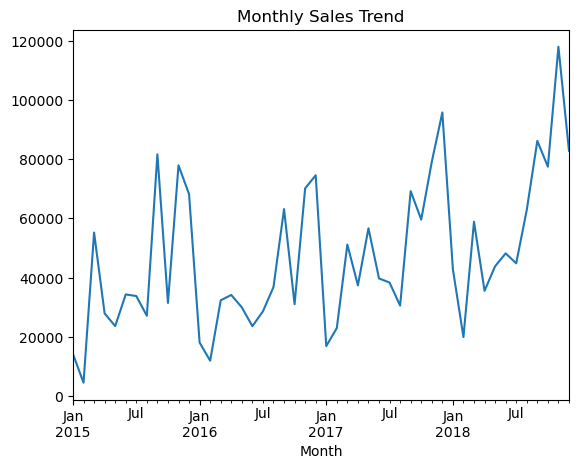

In [15]:
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.show()

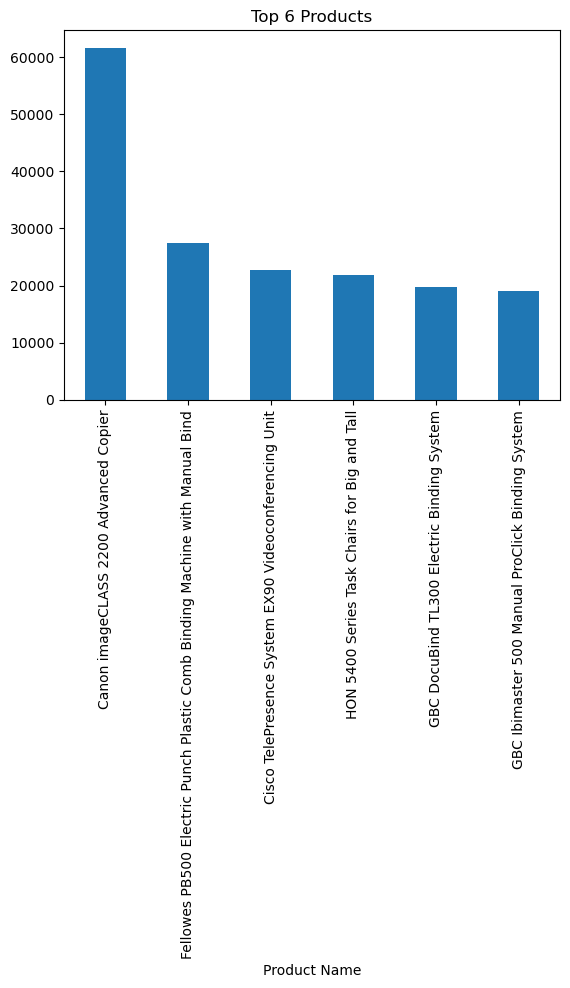

In [17]:
top_products.head(6).plot(kind='bar')
plt.title("Top 6 Products")
plt.show()